# Chapter 3 - Classical Text Classification

### Step 1 - A labelled corpus

In [1]:
import pandas as pd
import numpy as np

In [2]:
docs = [
    "the discount was great and saved money",
    "excellent pricing and good value",
    "great value for money",
    "the delivery was late and damaged",
    "terrible service and late delivery",
    "damaged item and poor service",
]

labels = np.array([1, 1, 1, 0, 0, 0])   # 1 = positive, 0 = negative

pd.DataFrame({"doc": docs, "label": labels})

,doc,label
0,the discount was great and saved money,1
1,excellent pricing and good value,1
2,great value for money,1
3,the delivery was late and damaged,0
4,terrible service and late delivery,0
5,damaged item and poor service,0


### Step 2 - The question Naive Bayes asks?

Given a document, which class is most likely?

    P(class | document)

We can't count that directly — we've never seen this exact document before.
Bayes' rule flips it into things we CAN count:

    P(class | doc) = P(doc | class) * P(class) / P(doc)

P(doc) is identical for every class, so it can't change which class wins.
Drop it:

    P(class | doc)  ∝  P(doc | class) * P(class)

Two pieces:
  P(class)      = the PRIOR. How common is this class? Just count documents.
  P(doc | class) = the LIKELIHOOD. If the class were positive, how likely
                   is it we'd see this document?

### Step 3 - The naive assumption

P(doc | class) is still impossible — we'd need to have seen this exact
sequence of words before.

So we assume every word is INDEPENDENT of every other word, given the class:

    P(doc | class) = P(w1|class) * P(w2|class) * P(w3|class) * ...

This is obviously FALSE. "late" makes "delivery" more likely. "New" makes
"York" more likely. Words are not independent.

But it turns an impossible problem into simple counting: we only need
per-word probabilities, not whole-document ones.

WHY IT WORKS ANYWAY: we don't need correct probabilities. We only need the
right class to score HIGHER than the wrong one. The assumption distorts both
scores, usually in the same direction, so the RANKING survives even though
the numbers are badly wrong. Naive Bayes is a poor probability estimator and
a good classifier — different jobs.

### Step 4 - Count the priors

In [3]:
N = len(docs)
p_pos = (labels == 1).sum() / N
p_neg = (labels == 0).sum() / N

print("P(positive) =", p_pos)
print("P(negative) =", p_neg)

P(positive) = 0.5
P(negative) = 0.5


### Step 5 - Count them

In [4]:
from collections import Counter

neg_words = [w for d, l in zip(docs, labels) if l == 0 for w in d.split()]
pos_words = [w for d, l in zip(docs, labels) if l == 1 for w in d.split()]

neg_counts = Counter(neg_words)
pos_counts = Counter(pos_words)

print("total negative words:", len(neg_words))
print("total positive words:", len(pos_words))
print(neg_counts)

total negative words: 16
total positive words: 16
Counter({'and': 3, 'delivery': 2, 'late': 2, 'damaged': 2, 'service': 2, 'the': 1, 'was': 1, 'terrible': 1, 'item': 1, 'poor': 1})


In [5]:
def p_word_given_class(word, counts, total):
    return counts[word] / total

print("P(late | neg) =", p_word_given_class("late", neg_counts, len(neg_words)))
print("P(late | pos) =", p_word_given_class("late", pos_counts, len(pos_words)))

P(late | neg) = 0.125
P(late | pos) = 0.0


### Step 6 - Why a single zero destroys everything

In [6]:
p_late_pos = 0.0        # 'late' never appears in a positive doc
p_great_pos = 0.083     # 'great' does

print(p_great_pos * p_late_pos)

0.0


A review says "great value but late delivery". Four positive-sounding words, one negative. Naive Bayes multiplies them together — and because one factor is zero, the entire product is zero.

**The fix — Laplace smoothing**

$$P(w \mid c) = \frac{\text{count}(w, c) + 1}{\text{total}(c) + |V|}$$

The numerator `+1` lifts every zero off the floor — a word you never saw
becomes unlikely, not impossible.

The denominator adds $|V|$, the vocabulary size, because we added 1 to each
of $|V|$ words, so the total grew by $|V|$. Without that correction the
probabilities would no longer sum to 1.

**Smoothing is regularization.** We accept a slightly worse fit on the
training data in exchange for not making catastrophic claims about unseen
data. Same principle as ridge regression shrinking coefficients.

In [7]:
vocab = sorted(set(neg_words) | set(pos_words))
V = len(vocab)

def p_word_given_class(word, counts, total, smooth=True):
    if smooth:
        return (counts.get(word, 0) + 1) / (total + V)
    return counts.get(word, 0) / total

print("vocabulary size:", V)
print()
print("raw      P(late|pos) =", p_word_given_class("late", pos_counts, len(pos_words), smooth=False))
print("smoothed P(late|pos) =", round(p_word_given_class("late", pos_counts, len(pos_words)), 4))
print()
print("raw      P(late|neg) =", round(p_word_given_class("late", neg_counts, len(neg_words), smooth=False), 4))
print("smoothed P(late|neg) =", round(p_word_given_class("late", neg_counts, len(neg_words)), 4))

vocabulary size: 19

raw      P(late|pos) = 0.0
smoothed P(late|pos) = 0.0286

raw      P(late|neg) = 0.125
smoothed P(late|neg) = 0.0857


In [8]:
# "great late" — one positive word, one negative word

for name, counts, total in [("positive", pos_counts, len(pos_words)),
                            ("negative", neg_counts, len(neg_words))]:
    raw = (p_word_given_class("great", counts, total, smooth=False) *
           p_word_given_class("late",  counts, total, smooth=False))
    sm  = (p_word_given_class("great", counts, total) *
           p_word_given_class("late",  counts, total))
    print(f"{name:9s}  raw={raw:.6f}   smoothed={sm:.6f}")

positive   raw=0.000000   smoothed=0.002449
negative   raw=0.000000   smoothed=0.002449


In [9]:
for test in ["great value", "late damaged service", "great late delivery"]:
    print(f"\n{test!r}")
    for name, counts, total, prior in [("positive", pos_counts, len(pos_words), p_pos),
                                       ("negative", neg_counts, len(neg_words), p_neg)]:
        score = prior
        for w in test.split():
            score *= p_word_given_class(w, counts, total)
        print(f"  {name:9s} {score:.10f}")


'great value'
  positive  0.0036734694
  negative  0.0004081633

'late damaged service'
  positive  0.0000116618
  negative  0.0003148688

'great late delivery'
  positive  0.0000349854
  negative  0.0001049563


### Step 7 - Log space

Multiplying small numbers tend to 0 in python. So take log and calculate

In [10]:
import math

def score_log(text, counts, total, prior):
    score = math.log(prior)
    for w in text.split():
        score += math.log(p_word_given_class(w, counts, total))
    return score

for test in ["great value", "late damaged service", "great late delivery"]:
    p = score_log(test, pos_counts, len(pos_words), p_pos)
    n = score_log(test, neg_counts, len(neg_words), p_neg)
    print(f"{test!r:26s} pos={p:8.3f}  neg={n:8.3f}  ->  {'positive' if p > n else 'negative'}")

'great value'              pos=  -5.607  neg=  -7.804  ->  positive
'late damaged service'     pos= -11.359  neg=  -8.063  ->  negative
'great late delivery'      pos= -10.261  neg=  -9.162  ->  negative


### Step 8 - Logistic regression

Naive Bayes only counting the words, no learning happening. Logistic regression learns. It starts with random weights, make prediction, check how wrong it was and adjusts.

It gives positive weight for a positive word and negative for negative word. 

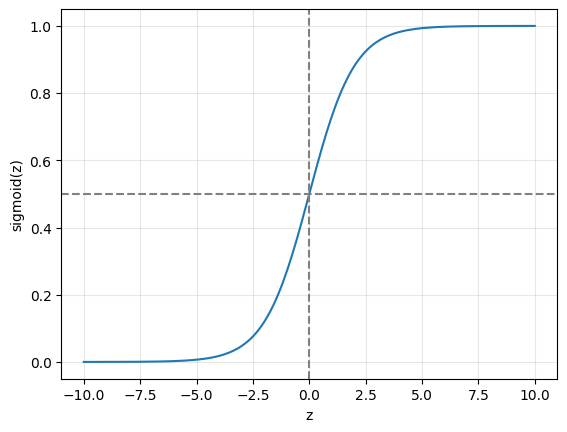

sigmoid( -6) = 0.0025
sigmoid( -2) = 0.1192
sigmoid(  0) = 0.5000
sigmoid(  2) = 0.8808
sigmoid(  6) = 0.9975


In [ ]:
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.axhline(0.5, ls="--", c="gray")
plt.axvline(0, ls="--", c="gray")
plt.xlabel("z"); plt.ylabel("sigmoid(z)"); plt.grid(alpha=0.3)
plt.show()

for val in [-6, -2, 0, 2, 6]:
    print(f"sigmoid({val:3d}) = {sigmoid(val):.4f}")

#### Learning the weights

Start random. Predict. Measure how wrong you were. Adjust. Repeat.

#### Cross-entropy loss

$$L = -\frac{1}{n}\sum_i \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

Read it in halves — only one term is ever active:

- When the true label $y = 1$, the second term vanishes and we are left with
  $-\log \hat{y}$. Small if $\hat{y}$ is near 1, exploding toward infinity as
  $\hat{y}$ approaches 0.
- When $y = 0$, the mirror image: $-\log(1 - \hat{y})$.

**Confident and wrong is punished enormously.** Predicting 0.99 when the truth
is 0 costs far more than predicting 0.6 and being wrong. That asymmetry is
deliberate — it discourages overconfidence.

#### Gradient descent

Adjust each weight in the direction that reduces the loss:

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

$\eta$ is the **learning rate** — how big a step to take. The derivative tells
us which way is downhill; $\eta$ decides how far to walk.

Chapter 4 derives this properly. For now: step downhill, repeatedly.

In [15]:
vocab = sorted(set(neg_words) | set(pos_words))
word_to_index = {w: i for i, w in enumerate(vocab)}

def bag_of_words(doc):
    v = np.zeros(len(vocab))
    for w in doc.split():
        if w in word_to_index:
            v[word_to_index[w]] += 1
    return v


In [17]:
X = np.array([bag_of_words(d) for d in docs])
y = labels

In [25]:
n_features = X.shape[1]
w = np.zeros(n_features)
b = 0.0
lr = 0.5

for epoch in range(1000):
    z = X @ w + b
    y_hat = sigmoid(z)

    loss = -np.mean(y *np.log(y_hat)+ (1-y)*np.log(1-y_hat))

    error = y_hat - y
    dw = (X.T @ error) / len(y)
    db = error.mean()

    w -= lr * dw
    b -= lr * db

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d}  loss={loss:.4f}")

epoch    0  loss=0.6931
epoch  200  loss=0.0102
epoch  400  loss=0.0051
epoch  600  loss=0.0034
epoch  800  loss=0.0025


In [35]:
pd.DataFrame({"word": vocab, "weight":w.round(3)}).sort_values("weight")

,word,weight
1,damaged,-2.143
9,late,-1.911
2,delivery,-1.911
14,service,-1.823
11,poor,-1.027
8,item,-1.027
15,terrible,-0.795
0,and,-0.444
16,the,0.046
18,was,0.046


#### Predict

In [36]:
def predict(text):
    v = bag_of_words(text)
    p = sigmoid(v @ w + b)
    return p, "positive" if p> 0.5 else "negative"

for t in ["great value", "late damaged service", "great late delivery"]:
    p, label = predict(t)
    print(f"{t!r:26s}  P(positive)={p:.4f}  ->  {label}")

'great value'               P(positive)=0.9855  ->  positive
'late damaged service'      P(positive)=0.0037  ->  negative
'great late delivery'       P(positive)=0.1598  ->  negative


## Step 9 - Evaluation

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (sigmoid(X @ w + b) > 0.5).astype(int)

print(confusion_matrix(y, y_pred))


[[3 0]
 [0 3]]


In [42]:
print("accuracy:", (y_pred == y).mean())

accuracy: 1.0


In [43]:
print(classification_report(y, y_pred, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
    positive       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [44]:
probs = sigmoid(X @ w + b)

for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pred = (probs > t).astype(int)
    tp = ((pred == 1) & (y == 1)).sum()
    fp = ((pred == 1) & (y == 0)).sum()
    fn = ((pred == 0) & (y == 1)).sum()
    prec = tp / (tp + fp) if tp + fp else 0
    rec = tp / (tp + fn) if tp + fn else 0
    print(f"threshold {t}:  precision={prec:.2f}  recall={rec:.2f}")

threshold 0.1:  precision=1.00  recall=1.00
threshold 0.3:  precision=1.00  recall=1.00
threshold 0.5:  precision=1.00  recall=1.00
threshold 0.7:  precision=1.00  recall=1.00
threshold 0.9:  precision=1.00  recall=1.00


## Step 10 - Class imbalance

In [47]:
y_imb = np.array([0]*95 + [1]*5)   # 95 negative, 5 positive
pred_lazy = np.zeros(100)

print("accuracy:", (pred_lazy == y_imb).mean())

accuracy: 0.95


Don't use accuracy on imbalanced data. Look at precision, recall, and the confusion matrix, and tune the threshold for whichever error is more expensive.

**The problem in te above example:** the loss is dominated by the majority class. The optimizer
learns that predicting "not fraud" for everything already scores 95%, so it
barely bothers learning what fraud looks like. Accuracy becomes meaningless
and training itself degrades.

### Fix 1 — Class weights

Tell the loss that mistakes on the minority cost more:

    mistake on a legitimate transaction:  costs 1
    mistake on a fraud transaction:       costs 19

Now the 50 fraud cases carry as much total weight as the 950 legitimate ones.
The data is unchanged — only the COST of each error type.

sklearn: `LogisticRegression(class_weight='balanced')`

### Fix 2 — Resampling

Change the data so the classes balance.

- **Oversampling** — copy each fraud row 19 times (950 vs 950).
  Risk: training on duplicates encourages memorization.
- **Undersampling** — delete legitimate rows until 50 remain (50 vs 50).
  Risk: throws away 900 rows of real data.
- **SMOTE** — generate SYNTHETIC fraud rows by interpolating between two real
  ones. Variety instead of duplicates.

### Fix 3 — Threshold tuning

Change nothing about training. Just lower the cutoff at prediction time.

Trained on mostly-legitimate data, the model is reluctant to output high
probabilities for fraud — a real fraud case might only score 0.3. At a 0.5
cutoff you miss it; at 0.2 you catch it.

This is what we did above. No retraining required.

### Which to use

1. **Threshold tuning** first — free, no retraining, often sufficient
2. **Class weights** second — one parameter, low risk
3. **Resampling** last — synthetic data brings its own problems